### Projectinformatie
**Opleiding:** Toegepaste Wiskunde & Data Science  
**Vak:** Beroepsproject 3.4  
**Begeleider:** R. Nolet  
**Datum:** 16-03-2026  

| Teamleden             | Studentnummer |
|----------------------|---------------|
| Murielle Tichelaar   | 500926485     |
| Nalini Bisessar      | 500874334     |
| Lushan Strack        | 500934278     |
| Dinand Voogt         | 500934202     |

# Evaluatie: Random Forest Model

In deze notebook wordt het getrainde Random Forest model geëvalueerd op de **testdata**.
Het model is gekozen als het beste model op basis van de hoogste cross-validatie ROC-AUC (0.982).

We laden het opgeslagen model in, maken voorspellingen op de testdata, en vergelijken de resultaten met de trainingsdata.

### 1. Libraries & Model laden

Het opgeslagen Random Forest model (inclusief preprocessing pipeline) wordt ingeladen met `joblib.load()`.
Daarnaast worden de evaluatiefuncties gedefinieerd.

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.dummy import DummyClassifier
from io import BytesIO
import base64
from IPython.display import display, HTML, Markdown

def display_executive_model_evaluation(y_true, y_pred, class_names=None):

    # Label mapping
    unique_labels = sorted(list(set(y_true)))

    if class_names:
        if len(class_names) != len(unique_labels):
            raise ValueError("class_names moet dezelfde lengte hebben als unieke labels.")
        label_map = dict(zip(unique_labels, class_names))
        y_true = [label_map[y] for y in y_true]
        y_pred = [label_map[y] for y in y_pred]
        used_labels = class_names
    else:
        used_labels = [str(l) for l in unique_labels]

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = report.get("macro avg", {})
    weighted = report.get("weighted avg", {})

    class_metrics = []
    for cls in used_labels:
        c = report.get(cls, {"precision":0,"recall":0,"f1-score":0,"support":0})
        class_metrics.append({
            "label": cls,
            "precision": c["precision"],
            "recall": c["recall"],
            "f1": c["f1-score"],
            "support": int(c["support"])
        })

    # Hover uitleg
    hover = {
        "accuracy": "Percentage correcte voorspellingen.",
        "macro": "Macro gemiddelde per klasse.",
        "weighted": "Weighted gemiddelde naar aantal observaties.",
        "precision": "Precision = TP / (TP + FP)",
        "recall": "Recall = TP / (TP + FN)",
        "f1": "F1-score = Harmonic mean van Precision en Recall.",
        "support": "Aantal observaties in deze klasse."
    }

    def info_icon(text):
        return f'<span style="font-size:10px; color:#9CA3AF; cursor:help; margin-left:4px;" title="{text}">ⓘ</span>'

    # HTML Rendering
    html = f"""
    <div style="
        font-family:'Segoe UI', Arial, sans-serif;
        max-width:850px;
        padding:40px;
        color:#111827;
        background:#FFFFFF;
        border-radius:8px;
        box-shadow: 0 8px 20px rgba(0,0,0,0.1);  
    ">

        <div style="font-size:22px; font-weight:600; margin-bottom:20px;">
            Model Performance
        </div>

        <div style="display:flex; justify-content:space-between; margin-bottom:30px;">

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Accuracy {info_icon(hover["accuracy"])}
                </div>
                <div style="font-size:36px; font-weight:600; margin-top:4px;">
                    {acc:.2%}
                </div>
            </div>

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Macro Average {info_icon(hover["macro"])}
                </div>
                <div style="margin-top:6px; font-size:14px;">
                    Precision: <b>{macro.get("precision",0):.2f}</b><br>
                    Recall: <b>{macro.get("recall",0):.2f}</b><br>
                    F1-score: <b>{macro.get("f1-score",0):.2f}</b>
                </div>
            </div>

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Weighted Average {info_icon(hover["weighted"])}
                </div>
                <div style="margin-top:6px; font-size:14px;">
                    Precision: <b>{weighted.get("precision",0):.2f}</b><br>
                    Recall: <b>{weighted.get("recall",0):.2f}</b><br>
                    F1-score: <b>{weighted.get("f1-score",0):.2f}</b>
                </div>
            </div>

        </div>

        <div style="height:1px; background:#E5E7EB; margin-bottom:25px;"></div>

        <div style="font-size:16px; font-weight:600; margin-bottom:12px;">
            Per Class Performance
        </div>

        <table style="width:100%; border-collapse:collapse; font-size:13px;">
            <thead>
                <tr style="text-align:left; border-bottom:2px solid #111827;">
                    <th style="padding:8px 0;">Class</th>
                    <th>Precision</th>
                    <th>Recall</th>
                    <th>F1-score</th>
                    <th>Support</th>
                </tr>
            </thead>
            <tbody>
    """

    for c in class_metrics:
        html += f"""
            <tr style="border-bottom:1px solid #E5E7EB;">
                <td style="padding:8px 0;">{c['label']}</td>
                <td><b>{c['precision']:.2f}</b></td>
                <td><b>{c['recall']:.2f}</b></td>
                <td><b>{c['f1']:.2f}</b></td>
                <td>{c['support']}</td>
            </tr>
        """

    html += """
            </tbody>
        </table>

        <div style="height:1px; background:#E5E7EB; margin:20px 0;"></div>

        <div style="font-size:16px; font-weight:600; margin-bottom:5px;">
            Confusion Matrix
        </div>

        <div id="confusion-matrix-container" style="display:flex; justify-content:center; width:100%; padding:0px 0;">
            <img src="data:image/png;base64,{confusion_matrix_img}" alt="Confusion Matrix" width="75%" />
        </div>

    </div>
    """

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    percent = cm / total * 100

    sns.set_style("white")
    plt.rcParams.update({"font.family": "DejaVu Sans"})

    fig, ax = plt.subplots(figsize=(8, 5))  # Verhoogde figuurafmetingen

    cmap = sns.light_palette("#1f4e79", as_cmap=True)

    heatmap = sns.heatmap(
        cm,
        annot=False,
        cmap=cmap,
        cbar=True,
        linewidths=0.6,
        linecolor="#ECECEC",
        square=True,
        ax=ax
    )

    threshold = cm.max() / 2

    labels_matrix = [["True Negative", "False Positive"],
                    ["False Negative", "True Positive"]]

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "#2b2b2b"

            ax.text(j + 0.5, i + 0.30,
                    labels_matrix[i][j],
                    ha='center', va='center',
                    fontsize=10,  # Kleinere lettertype
                    color=color,
                    alpha=0.9)
            
            # Groot getal in het midden
            ax.text(j + 0.5, i + 0.60,
                    f"{cm[i,j]:,}",
                    ha='center', va='center',
                    fontsize=22,  # Vergrote cijfers
                    fontweight='bold',
                    color=color)
            
            # Percentage onderin
            ax.text(j + 0.5, i + 0.85,
                    f"{percent[i,j]:.1f}%",
                    ha='center', va='center',
                    fontsize=10,  # Kleinere tekst
                    color=color,
                    alpha=0.85)

    fig.text(0.93, 0.02,
            f"Total samples: {total:,}",
            ha="right",
            va="bottom",
            fontsize=10,
            color="#6B7280")

    fig.subplots_adjust(top=0.95)

    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

    ax.set_xticklabels(used_labels)
    ax.set_yticklabels(used_labels, rotation=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Sla de plot op in geheugen
    img_buffer = BytesIO()
    plt.savefig(img_buffer, format='png')
    img_buffer.seek(0)

    # Zet het om naar base64
    confusion_matrix_img = base64.b64encode(img_buffer.read()).decode('utf-8')

    # Pas de HTML aan
    html = html.format(confusion_matrix_img=confusion_matrix_img)

    plt.close()

    # Display de volledige HTML
    display(HTML(html))

def evaluate_classification_model(y, p_pred, X, df):
    dummy = DummyClassifier(strategy="most_frequent", random_state=2026)
    dummy.fit(X, y)
    y_dummy = dummy.predict(X)
    proba_dummy = dummy.predict_proba(X)[:, 1]
    dummy_acc = accuracy_score(y, y_dummy)

    # Zet een classification report om in een rij van een dataframe
    def make_row(cr):
        return {
            'Accuracy':  cr['accuracy'],
            'Recall':    cr['1']['recall'],
            'Precision': cr['1']['precision'],
            'F1 Score':  cr['1']['f1-score']
        }

    thresholds = np.arange(0, 1, 0.01)
    plot_data = pd.DataFrame([
        make_row(classification_report(
            y, 
            p_pred > t, 
            zero_division=True, 
            output_dict=True)) for t in thresholds])
    plot_data.index = thresholds

    plt.figure(figsize=(20, 5), layout="constrained")

    # Plot 1: Distributie voorspelde kansen
    plt.subplot(1, 3, 1)
    sns.kdeplot(
        data=df,
        x=p_pred,
        hue="Churn",
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=1.5,

    )
    plt.xlim(0, 1)
    plt.title("Verdeling voorspelde kansen")
    plt.xlabel("Voorspelde kans op churn")
    plt.ylabel("Dichtheid")
    plt.grid(alpha=0.15)

    # Plot 2: Metrics vs threshold
    plt.subplot(1, 3, 2)
    sns.lineplot(data=plot_data)
    plt.axhline(dummy_acc, linestyle="--", linewidth=1.5, color="black", alpha=0.6, label="Baseline Accuracy")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.15)
    plt.title("Performance vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()

    # Plot 3: ROC curve
    ax = plt.subplot(1, 3, 3)
    roc_display = RocCurveDisplay.from_predictions(
        y,
        p_pred,
        ax=ax,
        plot_chance_level=True,
        curve_kwargs={"linewidth": 2}
    )
    plt.fill_between(roc_display.fpr, roc_display.tpr, color="#1f3b73", alpha=0.1)
    plt.title("ROC Curve")
    plt.grid(alpha=0.15)
    plt.show()
    
# Model inladen
model = joblib.load("random_forest_model.joblib")
print("Model geladen:", model)

Model geladen: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Call Failure', 'Complaints',
                                                   'Subscription Length',
                                                   'Seconds of Use',
                                                   'Frequency of use',
                                                   'Frequency of SMS',
                                                   'Distinct Called Numbers',
                                                   'Age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Age Group'])])),
                ('model',
                 RandomForestClassifier(max_features=3, n_estimators=200,
                                        random_state=42)

### 2. Testdata inladen

De testdata `data_test.csv` wordt ingeladen. Dit zijn klanten die het model nog nooit heeft gezien.

In [15]:
df_test = pd.read_csv("data_test.csv", sep=",", decimal=".")

target = "Churn"
X_test = df_test.drop(columns=[target])
y_test = df_test[target]

X_test.shape, y_test.shape

((855, 9), (855,))

### 3. Voorspelling & Beslissing tarief 2

Het model maakt een voorspelling van de churnkans voor elke klant in de testdata.
Op basis van een gepersonaliseerde threshold per klant wordt beslist wie tarief 2 aangeboden krijgt.

In [16]:
# Churnkans voorspellen
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Gepersonaliseerde threshold per klant
W1 = 0.1 * X_test["Frequency of SMS"] + 0.3 * X_test["Seconds of Use"]
W2 = 0.07 * X_test["Frequency of SMS"] + 0.2 * X_test["Seconds of Use"]

df_test["thresholds"] = (W1 - W2) / (W1 - 0.75 * W2)

# Beslissing
offer_tarief2 = (y_prob >= df_test["thresholds"])

n_tarief2 = offer_tarief2.sum()
print(f"Aantal klanten tarief 2: {n_tarief2}")
print(f"Totaal aantal klanten:   {len(df_test)}")
print(f"Percentage tarief 2:     {n_tarief2/len(df_test):.2%}")

Aantal klanten tarief 2: 76
Totaal aantal klanten:   855
Percentage tarief 2:     8.89%


### 4. Confusion Matrix

De confusion matrix laat zien hoe goed het model de churn correct voorspelt op de testdata.

Class,Precision,Recall,F1-score,Support
Blijft,0.96,0.97,0.97,734
Vertrekt,0.82,0.78,0.80,121

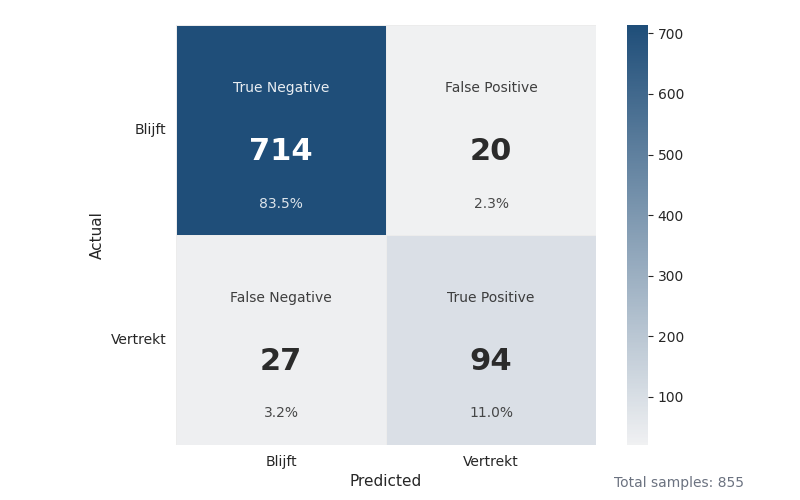

In [17]:
display_executive_model_evaluation(y_test, y_pred, class_names=["Blijft", "Vertrekt"])

### 5. Winstberekening

We berekenen de verwachte maandelijkse winst op basis van de modelstrategie en vergelijken dit met de optimale strategie.

In [18]:
sms_pm = X_test["Frequency of SMS"] / 9
min_pm = (X_test["Seconds of Use"] / 60) / 9

W1_pm = 0.1 * sms_pm + 0.3 * min_pm
W2_pm = 0.07 * sms_pm + 0.2 * min_pm

# Modelstrategie
E_tarief1_model = (1 - y_prob) * W1_pm
E_tarief2_model = (1 - 0.75 * y_prob) * W2_pm
totale_winst_model = (
    E_tarief2_model[offer_tarief2 == 1].sum() +
    E_tarief1_model[offer_tarief2 == 0].sum()
)

# Optimale strategie (op basis van werkelijke churn)
E_tarief1_max = (1 - y_test) * W1_pm
E_tarief2_max = (1 - 0.75 * y_test) * W2_pm
totale_winst_max = (
    E_tarief2_max[y_test == 1].sum() +
    E_tarief1_max[y_test == 0].sum()
)

# Berekeningen
verschil_winst = totale_winst_max - totale_winst_model
n_tarief2_optimaal = y_test.sum()
verschil_klanten = n_tarief2 - n_tarief2_optimaal
perc_tarief2 = n_tarief2 / len(X_test)
perc_tarief2_optimaal = n_tarief2_optimaal / len(X_test)

if verschil_klanten > 0:
    interpretatie = f"Het model biedt {verschil_klanten} klanten te veel tarief 2 aan (te agressief)."
elif verschil_klanten < 0:
    interpretatie = f"Het model biedt {-verschil_klanten} klanten te weinig tarief 2 aan (te voorzichtig)."
else:
    interpretatie = "Het model biedt precies het optimale aantal klanten tarief 2 aan."

interpretatie += f" Het model behaalt {totale_winst_model/totale_winst_max:.2%} van de maximale winst"
interpretatie += f" met een verschil van €{verschil_winst:.2f}."

pct_winst = totale_winst_model / totale_winst_max
bar_len = 30
filled_len = int(bar_len * pct_winst)
bar = '█' * filled_len + '-' * (bar_len - filled_len)

table_md = f"""
### Resultaten & Strategie

| Strategie | Tarief 2 (# klanten / %) | Winst per maand (€) |
|-----------|--------------------------|---------------------|
| Optimaal  | {int(n_tarief2_optimaal)} ({perc_tarief2_optimaal:.2%}) | {totale_winst_max:.2f} |
| Model     | {n_tarief2} ({perc_tarief2:.2%}) | {totale_winst_model:.2f} |

**Interpretatie:** {interpretatie}  
**Verschil klanten Tarief 2:** {verschil_klanten:+}  
**Winstverschil:** €{verschil_winst:.2f}  

**Percentage van maximale winst behaald:**  
`{bar}` {pct_winst:.2%}
"""

display(Markdown(table_md))


### Resultaten & Strategie

| Strategie | Tarief 2 (# klanten / %) | Winst per maand (€) |
|-----------|--------------------------|---------------------|
| Optimaal  | 121 (14.15%) | 2746.69 |
| Model     | 76 (8.89%) | 2708.78 |

**Interpretatie:** Het model biedt 45 klanten te weinig tarief 2 aan (te voorzichtig). Het model behaalt 98.62% van de maximale winst met een verschil van €37.91.  
**Verschil klanten Tarief 2:** -45  
**Winstverschil:** €37.91  

**Percentage van maximale winst behaald:**  
`█████████████████████████████-` 98.62%


### 6. Vergelijking trainingsdata vs testdata

| Metric                | Trainingsdata | Testdata    |
|-----------------------|---------------|-------------|
| Winst model (€/mnd)   | 6249.61       | 2708.78     |
| Winst optimaal (€/mnd)| 6270.30       | 2746.69     |
| % van max. winst      | 99.67%        | 98.62%      |
| Tarief 2 aangeboden   | 281 (14.09%)  | 76 (8.89%)  |
| Optimaal tarief 2     | 335 (16.79%)  | 121 (14.15%)|

**Wat valt op?**  
- Het model behaalt op de testdata **98.62%** van de maximale winst, wat dicht bij de 99.67% op de trainingsdata ligt. Dit suggereert dat het model goed generaliseert.
- Het model is op de testdata **voorzichtiger** dan op de trainingsdata: het biedt 45 klanten te weinig tarief 2 aan t.o.v. 54 op de trainingsdata.
- De absolute winst op de testdata is lager (€2708 vs €6249), wat logisch is omdat de testset kleiner is dan de trainingsset.
- Het winstverschil met de optimale strategie is op de testdata iets groter (€37.91 vs €20.69), maar nog steeds klein, het model presteert dus consistent op ongeziene data.